# Chapter 22: Safe Enough to Act

The most rewarding action is not always one the controller may take. A fast release can have high expected utility while lacking current approval. A different action can be authorized and still exceed a declared risk budget. Those are separate reasons to refuse execution.

This notebook compares three decision boundaries: unconstrained penalty maximization, penalty maximization after authority filtering, and reward maximization after both authority and expected-risk filtering. The example includes explicit abstention. Its purpose is to show what each mathematical formulation permits, rather than treating a large penalty as an invisible substitute for an action prohibition. The changed case relaxes only the expected-risk threshold.

**Outcome:** Compare penalty choice with hard authorization and expected-risk constraints.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later and the packages in `requirements.txt` at the top of the repository. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let reward R(a), expected adverse-event probability rho(a), penalty lambda>=0, and current permission A(a) describe an action. Penalty choice maximizes R(a)-lambda rho(a). A finite lambda trades reward against risk; it does not enforce rho(a)<=b or A(a)=true.

Authority filtering forms the set of actions whose permission predicate is true. The constrained choice further requires rho(a)<=b and maximizes reward within that intersection. An empty intersection returns no feasible choice. Abstention appears only if it is explicitly supplied with its own reward, risk, and permission.

An expected-risk limit is a statement about a probability or average, not a pathwise guarantee. A permitted action with rho=0.05 can still realize an adverse event. Similarly, a penalty-optimal action can violate the declared limit when reward is large enough. The method accepts supplied risks; it does not estimate them or prove that a real system's risk is below the given number.

## A calculation you can run

Provide action rows and declare the risk threshold and penalty separately. Validation checks finite rewards, probability domains, and exact permission booleans. The function returns unconstrained penalty choice, authorized penalty choice, constrained choice, and the number of feasible actions. Every alternative remains in the table with its flags and penalized value.

Reward and risk plots use separate vertical units. Compare selected labels with those figures instead of reading a reward bar as safety evidence. Run the default case and identify the first filter that removes each rejected action. In the changed case raise the expected-risk limit to 0.25 while preserving rewards, risks, and permissions. Predict whether a forbidden action can become available through that change.

The next cell finds the repository root and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file() and (p / "src" / "math_ai_agents").is_dir()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from a clone of the math-ai-agents repository.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 22
inputs = {'risk_limit': 0.1,
 'risk_penalty': 5,
 'actions': [{'name': 'fast-release', 'reward': 10, 'risk': 0.3, 'authorized': False},
             {'name': 'reviewed-release', 'reward': 5, 'risk': 0.05, 'authorized': True},
             {'name': 'risky-authorized', 'reward': 8, 'risk': 0.2, 'authorized': True},
             {'name': 'abstain', 'reward': 0, 'risk': 0, 'authorized': True}]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 22: risk-authority-contract
Which choices satisfy both current authority and a declared expected-risk limit?
Evidence: constructed teaching example

Calculated quantities:
{
  "unconstrained_penalty_choice": "fast-release",
  "authorized_penalty_choice": "risky-authorized",
  "constrained_choice": "reviewed-release",
  "feasible_count": 2
}

Interpretation:
A finite penalty can favor a forbidden or over-limit action. Authorization filters the action set; an expected-risk constraint filters authorized alternatives again.

Assumptions:
- Risks are supplied expected probabilities for the same adverse event.
- Authorization is a current hard predicate.

Limitations:
- Expected risk does not establish pathwise safety.
- Missing feasible actions requires abstention or a new authorized alternative.

Execution: completed locally; constructed inputs are not deployment measurements.


Fast-release has penalized value 10-5(0.3)=8.5 and wins unconstrained penalty choice, but it is unauthorized. Among authorized actions, risky-authorized has value 8-5(0.2)=7 and wins the penalty comparison. It exceeds the default risk limit 0.1.

The hard constrained choice is reviewed-release, with reward 5 and risk 0.05. Abstention is also feasible but has reward 0. When the limit changes to 0.25, risky-authorized becomes feasible and wins at reward 8. Fast-release stays forbidden because a risk-threshold change cannot create permission. The three selected labels therefore answer different questions.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

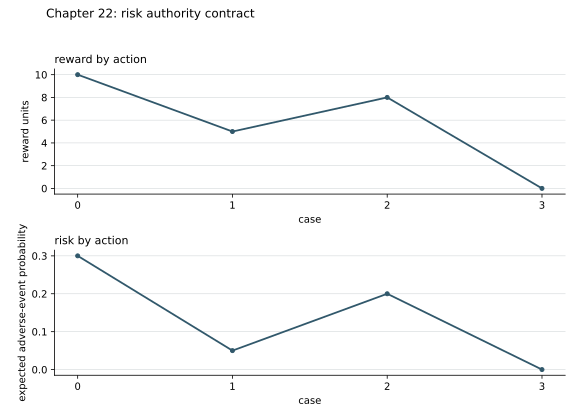

In [3]:
display(SVG(figure_svg(report)))

**Figure 22.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

A large penalty can look like a safety rule while leaving prohibited behavior available. If reward grows or the penalty is miscalibrated, the controller may choose the forbidden row. The hard authorization predicate avoids that particular tradeoff by removing the action before optimization.

Risk estimates also carry uncertainty. A supplied value 0.05 is not evidence of a bound unless an evaluation or formal process supports it. This notebook does not add confidence limits to supplied probabilities. When a limit must be conservative, provide a justified upper estimate or use a separate measurement design.

Pathwise properties need another representation. A mean-risk constraint cannot ensure that every trajectory respects a temporal invariant or that a tool never receives an unauthorized command. Use an explicit monitor and effect trace for those questions. Keep refusal and escalation alternatives visible when no permitted action meets the risk contract.

Chapter 22: risk-authority-contract
Which choices satisfy both current authority and a declared expected-risk limit?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "unconstrained_penalty_choice": "fast-release",
  "authorized_penalty_choice": "risky-authorized",
  "constrained_choice": "risky-authorized",
  "feasible_count": 3
}

Interpretation:
A finite penalty can favor a forbidden or over-limit action. Authorization filters the action set; an expected-risk constraint filters authorized alternatives again.

Assumptions:
- Risks are supplied expected probabilities for the same adverse event.
- Authorization is a current hard predicate.

Limitations:
- Expected risk does not establish pathwise safety.
- Missing feasible actions requires abstention or a new authorized alternative.

Execution: completed locally; constructed inputs are not deployment measurements.


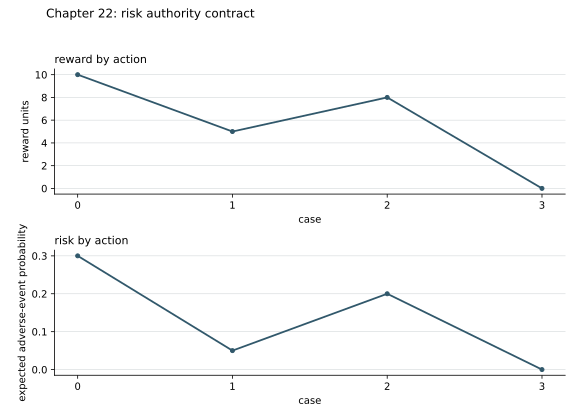

In [4]:
changed_inputs = {'risk_limit': 0.25,
 'risk_penalty': 5,
 'actions': [{'name': 'fast-release', 'reward': 10, 'risk': 0.3, 'authorized': False},
             {'name': 'reviewed-release', 'reward': 5, 'risk': 0.05, 'authorized': True},
             {'name': 'risky-authorized', 'reward': 8, 'risk': 0.2, 'authorized': True},
             {'name': 'abstain', 'reward': 0, 'risk': 0, 'authorized': True}]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 22.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer limit is zero. Act has risk 0.01 and is therefore infeasible, even though its penalized value is 19 under penalty 100. Wait has risk 0 and reward-1, so it is the only constrained choice. Negative reward does not invalidate a feasible refusal.

For local use, identify who owns the permission predicate and who owns the risk threshold. State the adverse event precisely and keep its probability denominator consistent across alternatives. A practical report should explain which rows fail authority, which fail expected risk, and which remain available. It should not convert a low average into a guarantee about every run.

In [5]:
transfer_inputs = {'risk_limit': 0,
 'risk_penalty': 100,
 'actions': [{'name': 'act', 'reward': 20, 'risk': 0.01, 'authorized': True},
             {'name': 'wait', 'reward': -1, 'risk': 0, 'authorized': True}]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 22: risk-authority-contract
Which choices satisfy both current authority and a declared expected-risk limit?
Evidence: constructed transfer example

Calculated quantities:
{
  "unconstrained_penalty_choice": "act",
  "authorized_penalty_choice": "act",
  "constrained_choice": "wait",
  "feasible_count": 1
}

Interpretation:
A finite penalty can favor a forbidden or over-limit action. Authorization filters the action set; an expected-risk constraint filters authorized alternatives again.

Assumptions:
- Risks are supplied expected probabilities for the same adverse event.
- Authorization is a current hard predicate.

Limitations:
- Expected risk does not establish pathwise safety.
- Missing feasible actions requires abstention or a new authorized alternative.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **risk_limit:** Maximum allowed adverse-event probability in [0,1].
- **risk_penalty:** Nonnegative utility deduction per unit probability.
- **actions:** Each row has name,reward:finite number,risk:probability,authorized:exact boolean. Abstention must be an explicit row.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch22.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 22: risk-authority-contract
Which choices satisfy both current authority and a declared expected-risk limit?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "unconstrained_penalty_choice": "act",
  "authorized_penalty_choice": "act",
  "constrained_choice": "wait",
  "feasible_count": 1
}

Interpretation:
A finite penalty can favor a forbidden or over-limit action. Authorization filters the action set; an expected-risk constraint filters authorized alternatives again.

Assumptions:
- Risks are supplied expected probabilities for the same adverse event.
- Authorization is a current hard predicate.

Limitations:
- Expected risk does not establish pathwise safety.
- Missing feasible actions requires abstention or a new authorized alternative.

Execution: completed locally; constructed inputs are not deployment measurements.


## Questions

1. Which default action wins the hard constraint?

2. Can risk_limit = 0.25 authorize fast-release?

3. Why does transfer choose wait despite negative reward?

Answers: [separate solutions](../solutions/ch22.md). Try the calculation before opening them.

## Summary

Reward penalties, expected-risk constraints, and hard authority are different decision rules. The notebook compares their choices explicitly and preserves every rejected alternative's reason. Relaxing risk can admit a previously over-limit action but cannot grant permission. The transfer case shows that a finite penalty can still prefer positive risk under a zero-risk contract. Use the constrained result within its declared probability model, while reserving pathwise and enforcement claims for separate evidence.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The matching skill is [`skills/22-risk-authority-contract`](../skills/22-risk-authority-contract/). It uses this notebook's computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 22.1

![Equation 22.1](../assets/math/eb14c1e8bbd95b7a8e74.svg)

Separates goal-seeking from permission: reward is maximized only among policies that meet every declared auxiliary-cost limit.

The same policy `\pi` appears in both ledgers, while each `i` names a distinct measured hazard and `d_i` names its limit.

LaTeX source, preserved for inspection:

```latex
\begin{aligned}
\text{maximize}_{\pi}\quad & \operatorname{Ret}^{\pi}\\
\text{subject to}\quad & \operatorname{Cost}_i^{\pi}\le d_i \quad \text{for every declared } i.
\end{aligned}\tag{22.1}
```

### Equation 22.2

![Equation 22.2](../assets/math/e3a0e835f74db5a1ee08.svg)

Turns one auxiliary cost into a fixed reward penalty so ordinary reward optimization can rank policies by one blended score.

`\lambda_{\mathrm{safe}}` sets a constant exchange rate between reward units and the first declared cost's units.

LaTeX source, preserved for inspection:

```latex
\operatorname{Score}_{\lambda_{\mathrm{safe}}}(\pi)
=\operatorname{Ret}^{\pi}-\lambda_{\mathrm{safe}}\operatorname{Cost}_1^{\pi}.
\tag{22.2}
```

### Equation 22.3

![Equation 22.3](../assets/math/371c8675bdb06b88d9bb.svg)

Bounds one update's modeled excess over cost limit by a term controlled by policy-step size, discounting, and constraint advantage.

The right side is `d_i` plus a nonnegative allowance, so the displayed result permits bounded violation rather than asserting satisfaction.

LaTeX source, preserved for inspection:

```latex
\operatorname{Cost}_i^{\pi_{k+1}}
\le d_i+
\frac{\sqrt{2\delta}\,\gamma\,\epsilon_i}{(1-\gamma)^2}.
\tag{22.3}
```

### Equation 22.4

![Equation 22.4](../assets/math/23fd856a63c4e5644b78.svg)

Reserves room below a deployment cost limit for known modeling, approximation, sampling, and update-bound exposure.

Optimization targets a stricter internal ceiling, leaving `\varepsilon_{\mathrm{safe}}` between measured planning cost and external limit `d_i`.

LaTeX source, preserved for inspection:

```latex
\operatorname{Cost}_i^{\pi}
\le d_i-\varepsilon_{\mathrm{safe}},
\qquad \varepsilon_{\mathrm{safe}}>0.
\tag{22.4}
```

### Equation 22.5

![Equation 22.5](../assets/math/efc01bbeb46ffdf27496.svg)

Replaces a mean-cost target with a declared upper-tail severity measure for episode cost `C`.

The threshold `z` searches tail cutoffs, while `1/(1-\alpha)` scales severity beyond each cutoff.

LaTeX source, preserved for inspection:

```latex
\operatorname{CVaR}_{\alpha}(C)
= \inf_{z\in\mathbb R}\left[z+\frac{1}{1-\alpha}\,\mathbb E[(C-z)_+]\right].
\tag{22.5}
```

### Equation 22.6

![Equation 22.6](../assets/math/e765c8011cb6df6a9d96.svg)

Carries a declared finite-horizon risk budget forward, preventing one charged action from spending more authority than remains.

`b_t` is an accounting state, while `\widehat r_t(a_t)` needs its own calibration and threat-model evidence.

LaTeX source, preserved for inspection:

```latex
b_{t+1}=b_t-\widehat r_t(a_t),\qquad b_0=B,\qquad \widehat r_t(a_t)\le b_t.
\tag{22.6}
```